In [37]:
import pandas as pd
from google.cloud import bigquery
import seaborn as sns
import numpy as np

# --- CONFIGURATION ---
# 1. Your GCP Project ID (Found in Cloud Console dashboard)
PROJECT_ID = "dev-poet-480917-e3" 

# 2. Your Dataset and Table Name
# Format: `project.dataset.table`
TABLE_ID = "dev-poet-480917-e3.restaurant_data.cleaned_500_restaurants"

# --- CONNECT & EXTRACT ---
# This uses the credentials you set up with gcloud
client = bigquery.Client(project=PROJECT_ID)

# Write your query (Select all columns since it's cleaned)
query = f"""
    SELECT *
    FROM `{TABLE_ID}`
"""

print("⏳ Extracting data from BigQuery...")

# Run the query and convert to Pandas DataFrame
df = client.query(query).to_dataframe()

# --- VALIDATION ---
print("✅ Success!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Show the first 5 rows to verify boolean/cost cleaning
df.head()

⏳ Extracting data from BigQuery...


c:\Users\divye\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✅ Success!
Rows: 9551, Columns: 18


,Restaurant_ID,Restaurant_Name,Country_Code,City,Latitude,Longitude,Cuisines,AC_of_Two,Currency,Tab_book,Online_Del,Now_Del,Order_Menu,Agg_rating,Price_Range,Rating_color,Rating_text,Votes
0,3326,The Mirch Masala,1,New Delhi,28.687307,77.173635,North Indian,650,Indian Rupees(Rs.),0,0,0,0,3.2,2,Orange,Average,22
1,6286,Bengali Pastry Shop & Snack Bar,1,New Delhi,28.629522,77.231968,"North Indian, South Indian, Chinese",550,Indian Rupees(Rs.),0,0,0,0,3.2,2,Orange,Average,70
2,7352,Domino's Pizza,1,New Delhi,28.557597,77.164546,"Pizza, Fast Food",700,Indian Rupees(Rs.),0,0,0,0,3.3,2,Orange,Average,90
3,18483372,Sky On 57,184,Singapore,1.282661,103.860005,"Chinese, Continental, Singaporean",300,Dollar($),0,0,0,0,3.4,4,Orange,Average,34
4,4166,Red - Bellagio,1,New Delhi,28.696251,77.180046,Chinese,1500,Indian Rupees(Rs.),1,1,0,0,3.4,3,Orange,Average,137


Price Category


In [38]:
price_map = {1: "Budget",2: "Moderate", 3:"Expensive",4:"Premium"}
df["price_cat"] = df["Price_Range"].map(price_map)

print(df["price_cat"].head())


0     Moderate
1     Moderate
2     Moderate
3      Premium
4    Expensive
Name: price_cat, dtype: object


Value for money score

In [39]:
df["value_money_score"] = df["Agg_rating"] / df["AC_of_Two"]
#print(df["value_money_score"])

df_sorted = df.sort_values(by="value_money_score",ascending=False)
print(df_sorted["value_money_score"])


3285    inf
2862    inf
3898    inf
8538    inf
8594    inf
       ... 
7627    0.0
7628    0.0
7629    0.0
7630    0.0
1659    0.0
Name: value_money_score, Length: 9551, dtype: Float64


Putting the median cost in place of zero or negative in AC_of_two

In [40]:
median_cost_by_range = (
    df[df['AC_of_Two'] > 0]
    .groupby('Price_Range')['AC_of_Two']
    .median()
)
df["AC_of_Two_imputed"] = df["AC_of_Two"]

df.loc[df["AC_of_Two_imputed"]<=0,"AC_of_Two_imputed"] = (
    df.loc[df["AC_of_Two_imputed"]<=0,"Price_Range"].map(median_cost_by_range)
)
print(df["AC_of_Two_imputed"].head())
print(df["AC_of_Two"].head())

df_sorted = df.sort_values(by="AC_of_Two",ascending=True)
print(df_sorted["AC_of_Two"].head(),"\n",df_sorted["AC_of_Two_imputed"].head())


0     650
1     550
2     700
3     300
4    1500
Name: AC_of_Two_imputed, dtype: Int64
0     650
1     550
2     700
3     300
4    1500
Name: AC_of_Two, dtype: Int64
6468    0
8594    0
6700    0
4260    0
1790    0
Name: AC_of_Two, dtype: Int64 
 6468    300
8594    300
6700    300
4260    300
1790    300
Name: AC_of_Two_imputed, dtype: Int64


Comparison between the AC_of_two vs AC_of_two(imputed data)

In [41]:
df["AC_of_Two_zflag"] = (df["AC_of_Two"]<=0).astype(int)



df["AC_of_Two_imputed_zflag"] = (df["AC_of_Two_imputed"]<=0).astype(int)
print(df["AC_of_Two_imputed_zflag"].value_counts(),'\n',df["AC_of_Two_zflag"].value_counts())




AC_of_Two_imputed_zflag
0    9551
Name: count, dtype: int64 
 AC_of_Two_zflag
0    9533
1      18
Name: count, dtype: int64


Calculated Value for money score from Avg cost of two vs rating

In [42]:
df["value_money_score"] = df["Agg_rating"] / df["AC_of_Two_imputed"]
print(df["value_money_score"])

df_sorted = df.sort_values(by="value_money_score",ascending=False)
print(df_sorted["value_money_score"])

0       0.004923
1       0.005818
2       0.004714
3       0.011333
4       0.002267
          ...   
9546    0.003143
9547    0.001467
9548    0.005375
9549        0.41
9550        0.11
Name: value_money_score, Length: 9551, dtype: Float64
9088    0.542857
2182    0.542857
3689    0.528571
670     0.514286
9248        0.49
          ...   
8024         0.0
8023         0.0
8022         0.0
8021         0.0
5532         0.0
Name: value_money_score, Length: 9551, dtype: Float64


Boxplot for Money score vs Price Range

<Axes: xlabel='Price_Range', ylabel='value_money_score'>

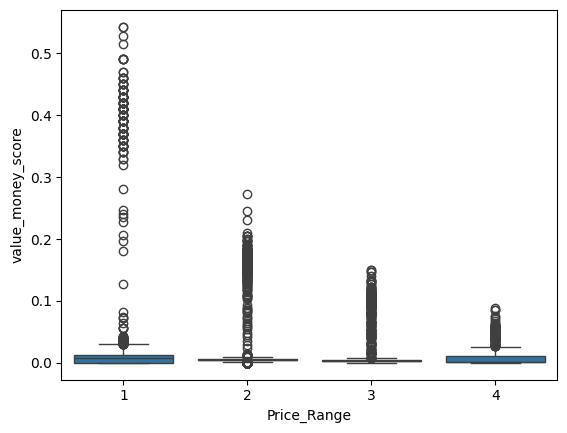

In [43]:

sns.boxplot(x='Price_Range', y='value_money_score', data=df)

Getting a percentile rank for affordable resturant with valuable reviews and 
Mapping with labels

In [44]:
df['value_percentile'] = df['value_money_score'].rank(pct=True)
df['value_segment_money_score'] = pd.cut(
    df['value_percentile'],
    bins=[0,0.25,0.5,0.75,1],
    labels=['Low','Moderate','Acceptable','Good']
)
print(df['value_percentile'],'\n',df['value_segment_money_score'])


0       0.472568
1       0.548529
2       0.456340
3       0.805151
4       0.279447
          ...   
9546    0.339022
9547    0.246205
9548    0.511151
9549    0.993666
9550    0.959167
Name: value_percentile, Length: 9551, dtype: float64 
 0         Moderate
1       Acceptable
2         Moderate
3             Good
4         Moderate
           ...    
9546      Moderate
9547           Low
9548    Acceptable
9549          Good
9550          Good
Name: value_segment_money_score, Length: 9551, dtype: category
Categories (4, object): ['Low' < 'Moderate' < 'Acceptable' < 'Good']


Getting a weighted ranking from Agg_rating and votes

In [45]:
C = df['Agg_rating'].mean()

m = df['Votes'].quantile(0.75)

df['weighted_ranking'] = (
    (df['Votes'] / (df['Votes'] + m))* df['Agg_rating'] + (m / (df['Votes'] + m) * C)
    )

print(df['weighted_ranking'].head(10))

0    2.743101
1    2.852211
2    2.924409
3    2.817542
4    3.041397
5    2.682312
6    2.694246
7    2.676813
8    2.786358
9    2.742909
Name: weighted_ranking, dtype: Float64


In [46]:
df_sort = df.sort_values(by="weighted_ranking",ascending=False)
print(df_sort['weighted_ranking'].head(10))


7563    4.852008
6990     4.84742
5631    4.813302
4671    4.793637
7561    4.776486
6611    4.775115
3667     4.77474
3459    4.758302
3276    4.744689
4670    4.736807
Name: weighted_ranking, dtype: Float64


Creating the popularity level from Votes

In [47]:
df['popularity_level'] = pd.cut(
    df['Votes'],
    bins=[0, 50, 200, 1000, df['Votes'].max()],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print(df['popularity_level'])

0             Low
1          Medium
2          Medium
3             Low
4          Medium
          ...    
9546         High
9547         High
9548       Medium
9549       Medium
9550    Very High
Name: popularity_level, Length: 9551, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Very High']


Calculating the Number of Cuisines per Restaurant

In [48]:
df['num_cuisines'] = df['Cuisines'].apply(
    lambda x: len(x.split(',')) 
    if pd.notnull(x) and x!='Not Specified'
    else 0
)

print(df['num_cuisines'])
print()

0       1
1       3
2       2
3       3
4       1
       ..
9546    6
9547    3
9548    4
9549    1
9550    1
Name: num_cuisines, Length: 9551, dtype: int64



Getting the convience score from boolean expressions

In [49]:
df['convience_score'] = (df['Tab_book']+
                         df['Online_Del']+
                         df['Now_Del']+
                         df['Order_Menu'])



Calculating the Log1 of votes to normalize the value 

In [51]:
df['log_votes'] = np.log1p(df['Votes'])
print(df['log_votes'].head(10))

0    3.135494
1     4.26268
2     4.51086
3    3.555348
4    4.927254
5    1.791759
6    2.302585
7    4.094345
8    3.663562
9    3.688879
Name: log_votes, dtype: Float64


Average rating of Cities

In [55]:
city_avg = df.groupby('City')['weighted_ranking'].mean()
df['city_avg_rating'] = df['City'].map(city_avg)
print(df['city_avg_rating'].head())

0    2.860136
1    2.860136
2    2.860136
3    2.845674
4    2.860136
Name: city_avg_rating, dtype: Float64


In [ ]:
final_cols = [
    'Restaurant_ID',
    'Restaurant_Name',
    'City',
    'city_avg_rating',
    'Cuisines',
    'num_cuisines',
    'AC_of_Two_imputed',
    'Price_Range',
    'weighted_ranking',
    'value_money_score',
    'value_percentile',
    'value_segment_money_score',
    'convience_score',
    'popularity_level',
    'Agg_rating',
    'Rating_text',
    'Rating_color',
    'Votes',
    'log_votes',  
]

df_features = df[final_cols].copy()

df_features.to_csv('C:\Users\divye\Data_science_projects\500_restaurants_analysis\data\restaurants_features.csv',index=False)


OSError: Cannot save file into a non-existent directory: 'data'